# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [1]:
# DO NOT CHANGE
import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [2]:
bandit0 = BanditProblem(0)

In [3]:
bandit0.get_num_arms()

3

In [4]:
bandit0.get_reward(arm=0)

1.8255111545554434

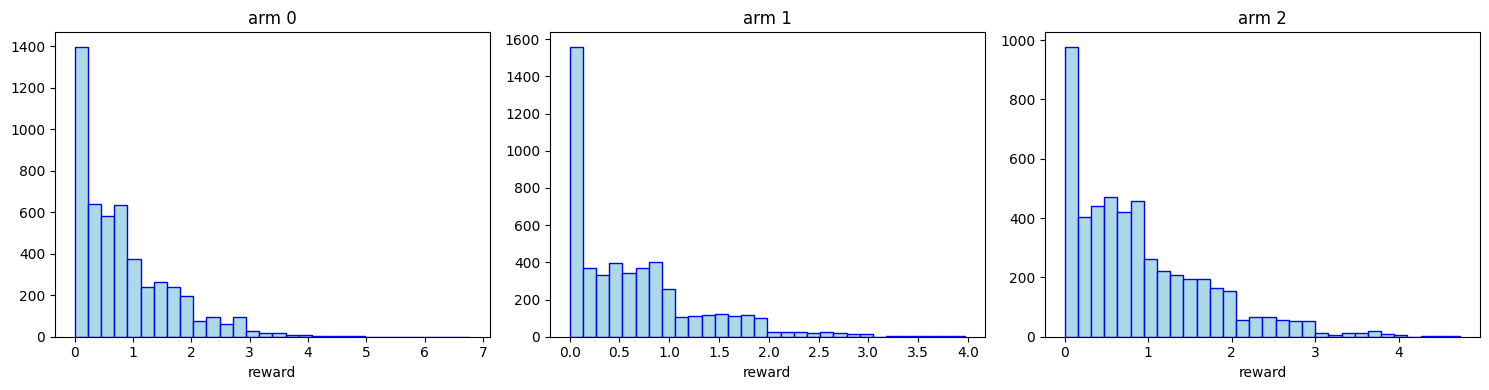

arm 0: min=0.000 max=6.782 mean=0.828
arm 1: min=0.000 max=3.973 mean=0.630
arm 2: min=0.000 max=4.738 mean=0.891


In [5]:
# YOUR CHANGES HERE

import matplotlib.pyplot as plt

bandit0 = BanditProblem(0)
K = bandit0.get_num_arms()

# many sample per arm 
n_samples = 5000
samples = {arm: [bandit0.get_reward(arm) for _ in range(n_samples)] for arm in range(K)}

fig, axes = plt.subplots(1, K, figsize=(15, 4))
for arm in range(K):
    axes[arm].hist(samples[arm], bins=30, color = 'lightblue', edgecolor='blue')
    axes[arm].set_title(f"arm {arm}")
    axes[arm].set_xlabel("reward")
plt.tight_layout()
plt.show()

for arm in range(K):
    vals = samples[arm]
    print(f"arm {arm}: min={min(vals):.3f} max={max(vals):.3f} mean={sum(vals)/len(vals):.3f}")

The histograms from above show that rewards are on a continuous scale and are not restricted to 0/1 which disqualifies Thompson sampling as being the appropriate bandit algorithm as that relies on the Beta-Bernoulli conjugate update with binary rewards. The reward algorithm in the explanation defines a known upper bound of 9 and means that I can rescale rewards into [0, 1] and apply UCB1 as the appropriate algorithm. 

In [6]:
with open("algorithm-choice.txt", "w") as f:
    f.write(
        "The histograms from above show that rewards are on a continuous scale and are "
        "not restricted to 0/1 which disqualifies Thompson sampling as being the "
        "appropriate bandit algorithm as that relies on the Beta-Bernoulli conjugate "
        "update with binary rewards. The reward algorithm in the explanation defines a "
        "known upper bound of 9 and means that I can rescale rewards into [0, 1] and "
        "apply UCB1 as the appropriate algorithm."
    )

Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives.
Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [7]:
# YOUR CHANGES HERE

import math
import numpy as np

bandit = BanditProblem(2026)
K = bandit.get_num_arms()
T = 1000

# reward < 9 - defined from reward = Uniform(0,1) * Binomial(n, p) and n <= 9
upperbound = 9.0

counts = [0] * K   # how many time ea arm is pulled
totals = [0.0] * K # sum of rewards per arm 
history_actions = []
history_rewards = []

In [8]:
def pull(arm):
    r = bandit.get_reward(arm)
    counts[arm] += 1
    totals[arm] += r
    history_actions.append(arm)
    history_rewards.append(r)
    return r

In [9]:
#initalise
for arm in range(K):
    pull(arm)

In [10]:
for t in range(K, T):
    n = t  # total actions so far
    bounds = []
    for arm in range(K):
        avg_scaled = (totals[arm] / counts[arm]) / upperbound
        bound = avg_scaled + math.sqrt(2 * math.log(n) / counts[arm])
        bounds.append(bound)
    chosen = int(np.argmax(bounds))
    pull(chosen)


print("Final Pull Counts:", counts)
print("Final Average Rewards:", [totals[a] / counts[a] for a in range(K)])

Final Pull Counts: [605, 211, 184]
Final Average Rewards: [1.2402355291657101, 0.29068276980288715, 0.124179628258903]


Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [11]:
# YOUR CHANGES HERE
import pandas as pd
history_df = pd.DataFrame({
    "action": history_actions,
    "reward": history_rewards
})

history_df.to_csv("history.tsv", sep="\t", index=False)

Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [12]:
# YOUR CHANGES HERE
actions = history_df.groupby("action")["reward"].agg(
    min_reward="min", mean_reward="mean", max_reward="max"
).reset_index()

actions.to_csv("actions.tsv", sep="\t", index=False)
actions

,action,min_reward,mean_reward,max_reward
0,0,0.0,1.240236,6.564312
1,1,0.0,0.290683,1.857291
2,2,0.0,0.124180,0.957842


Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [14]:
# YOUR CHANGES HERE
T = 1000
mu_hat = actions.set_index("action")["mean_reward"]
best_mu = mu_hat.max()

results = []

#uniform - pick an arm uniformaly at random 
uniform_expected_reward = mu_hat.mean()
results.append({"strategy": "uniform", "regret": T * (best_mu - uniform_expected_reward)})

# just i = pick arm i always
for i in range(K):
    results.append({"strategy": f"just-{i}", "regret": T * (best_mu - mu_hat[i])})

# actual: use pt2 to match
actual_expected_reward = sum(counts[a] * mu_hat[a] for a in range(K)) / T
results.append({"strategy": "actual", "regret": T * (best_mu - actual_expected_reward)})

strategies = pd.DataFrame(results)
strategies

,strategy,regret
0,uniform,688.536220
1,just-0,0.000000
2,just-1,949.552759
3,just-2,1116.055901
4,actual,405.709918


Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [16]:
# YOUR CHANGES HERE
strategies.to_csv("strategies.tsv", sep="\t", index=False)

Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.